# Import Data


In [ ]:
from datastream.utils import *
import pandas as pd
from datastream.ff_data import *

# ── 1. import ──────────────────────────────────────────────────────────────
df = pd.read_feather(
    "/Users/ralfkellner/Datastream/PriceData/US/processed/US_data_panel_filtered_0.15.feather"
)

# ── 2. monthly returns ─────────────────────────────────────────────────────
# determine_monthly_returns now keeps the first (NaN-return) row per stock,
# which carries the MarketCAP needed as t-1 weight in the first portfolio month.
monthly_returns = (
    df.groupby("Stock", group_keys=True)[["Date", "ReturnIndex", "MarketCAP"]]
    .apply(lambda x: determine_monthly_returns(
        x, price_column="ReturnIndex", date_column="Date"
    ))
    .reset_index()
    .sort_values(["Date", "Stock"])
    .dropna(subset=["MonthlyReturn"])   # drop the first obs per stock (NaN return)
    .reset_index(drop=True)
)

# ── 3. portfolios ──────────────────────────────────────────────────────────
# Both functions lag MarketCAP internally and share the same eligible universe.
ew_pf = equally_weighted_portfolio(
    monthly_returns, "MonthlyReturn", "MarketCAP", "Stock", "Date"
)
vw_pf = value_weighted_portfolio(
    monthly_returns, "MonthlyReturn", "MarketCAP", "Stock", "Date"
)

# ── 4. align on a common Period index ─────────────────────────────────────
def to_period_index(df, date_col, col_rename, period="M"):
    return (
        df.set_index(pd.PeriodIndex(df[date_col].dt.to_period(period)))
        .drop(columns=date_col)
        .rename(columns={"PortfolioReturn": col_rename})
    )

ew = to_period_index(ew_pf, "Date", "EW_PF")
vw = to_period_index(vw_pf, "Date", "MV_PF")
pf = ew.join(vw)

# ── warm the cache (run once per session, or on notebook startup) ──────────
# Downloads anything missing; prompts once if any entry is > 90 days old.
prefetch_ff_cache()

# ── then use exactly as before ─────────────────────────────────────────────
ff3m = get_ff_factors(3, "monthly")

# Descriptive Comparison to Fama-French Market Value Portfolio

In [24]:
compare_to_mkt = pd.merge(pf, (ff3m["Mkt-RF"] + ff3m["RF"]).to_frame("Mkt"), left_index = True, right_index = True)
compare_to_mkt.describe()

,EW_PF,MV_PF,Mkt
count,385.000000,385.000000,385.000000
mean,0.009861,0.009534,0.009615
std,0.042523,0.043204,0.044456
min,-0.192271,-0.172384,-0.171200
25%,-0.012120,-0.016757,-0.017500
50%,0.013392,0.015007,0.015300
75%,0.035517,0.035985,0.037700
max,0.156292,0.127997,0.136000


In [38]:
compare_to_mkt.corr()

,EW_PF,MV_PF,Mkt
EW_PF,1.000000,0.919753,0.916621
MV_PF,0.919753,1.000000,0.998884
Mkt,0.916621,0.998884,1.000000


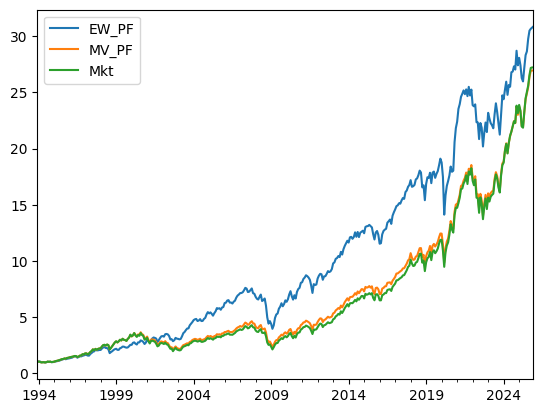

In [27]:
cumulative_return_plot = (1 + compare_to_mkt).cumprod().plot()

# Fama-French Regression

In [35]:
import statsmodels.api as sm

regression_data = pd.merge(pf, ff3m, left_index = True, right_index = True)
X = regression_data.loc[:, ["Mkt-RF", "SMB", "HML"]]
X = sm.add_constant(X)

y_ew = regression_data["EW_PF"] - regression_data["RF"]
y_mv = regression_data["MV_PF"] - regression_data["RF"]

results_ew = sm.OLS(y_ew, X).fit()
results_mv = sm.OLS(y_mv, X).fit()

print(results_mv.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 6.272e+04
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:49:17   Log-Likelihood:                 1858.2
No. Observations:                 385   AIC:                            -3708.
Df Residuals:                     381   BIC:                            -3693.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      1.054      0.2

In [40]:
print(results_ew.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     2664.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          3.45e-255
Time:                        11:49:52   Log-Likelihood:                 1264.5
No. Observations:                 385   AIC:                            -2521.
Df Residuals:                     381   BIC:                            -2505.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.000      2.707      0.0